In [ ]:
!pip install konlpy

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from konlpy.tag import Okt
import warnings
import platform
from matplotlib import font_manager, rcParams

warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df90 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1990.csv")
df91 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1991.csv")
df92 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1992.csv")
df93 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1993.csv")
df94 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1994.csv")
df95 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1995.csv")
df96 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1996.csv")
df97 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1997.csv")
df98 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1998.csv")
df99 = pd.read_csv("/content/drive/MyDrive/캡스톤EDA/csv 파일/melon_chart_1999.csv")

In [ ]:
# 1. df20 ~ df29 concat (예: 2010년대)
dfs = [globals()[f'df{i}'] for i in range(90, 100)]
df_90s = pd.concat(dfs, ignore_index=True)

In [ ]:
# 2. 'lyric' 컬럼 전처리
lyrics = df_90s['lyric'].dropna().astype(str)
text = ' '.join(lyrics)
text = re.sub(r'[^가-힣a-zA-Z\s]', '', text)  # 영어 포함된 정제

In [ ]:
from konlpy.tag import Okt
import re

# 반복된 단어 제거 (예: '사랑 사랑', '나나 나나')
text = re.sub(r'\b(\w+)\s+\1\b', '', text)

# 3. 형태소 분석 + 불용어 제거 + 영어 단어 추출
okt = Okt()
stopwords = set([
    '는', '은', '이', '가', '을', '를', '에', '의', '도', '다', '고', '서', '한', '하',
    '해', '더', '것', '들', '지', '또', '때', '요', '듯', '좀', '듯이', '으로', '하며',
    '하고', '해서', '그', '저', '아', '야', '나', '니', '늘', '무슨', '왜', '어', '면'
    # '사랑 사랑' 제거는 위 정규식에서 처리했으므로 stopwords에서는 제거
])

# 3-1. 한글 명사 추출 및 불용어 제거
korean_tokens = okt.nouns(text)
korean_filtered = [word for word in korean_tokens if word not in stopwords and len(word) > 1]

# 3-2. 영어 단어 추출 (길이 2 이상 단어만)
english_tokens = re.findall(r'\b[a-zA-Z]{2,}\b', text)

# 최종 결과 결합
all_tokens = korean_filtered + english_tokens


In [ ]:
# 4. 워드클라우드 준비
final_text = ' '.join(all_tokens)

In [ ]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# matplotlib 설정
import matplotlib.pyplot as plt
from matplotlib import rcParams, font_manager

# 드라이브에 있는 나눔스퀘어 폰트 경로 지정
font_path = '/content/drive/MyDrive/캡스톤EDA/NanumGothic.ttf'  # 본인의 경로에 맞게 수정

# 폰트 설정
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


폰트 이름: NanumGothic


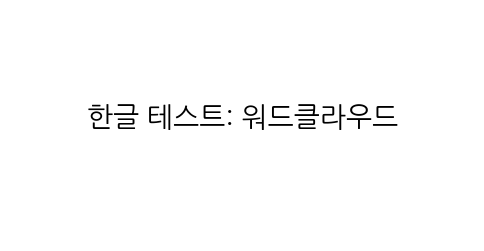

In [ ]:
from matplotlib import font_manager, rcParams
import matplotlib.pyplot as plt

# 구글 드라이브 폰트 경로
font_path = '/content/drive/MyDrive/캡스톤EDA/NanumGothic.ttf'

# FontProperties 생성
font_prop = font_manager.FontProperties(fname=font_path)

# 실제 시스템 인식 이름 확인
font_name = font_prop.get_name()
print(f"폰트 이름: {font_name}")  # 'NanumSquare_ac' 출력됨

# matplotlib 전체 설정
rcParams['font.family'] = font_name  # 그래도 설정해두기

# 간단한 테스트 그래프 (!!! fontproperties 지정하기 !!!)
plt.figure(figsize=(6, 3))
plt.text(0.5, 0.5, '한글 테스트: 워드클라우드', fontproperties=font_prop, fontsize=20, ha='center')
plt.axis('off')
plt.show()


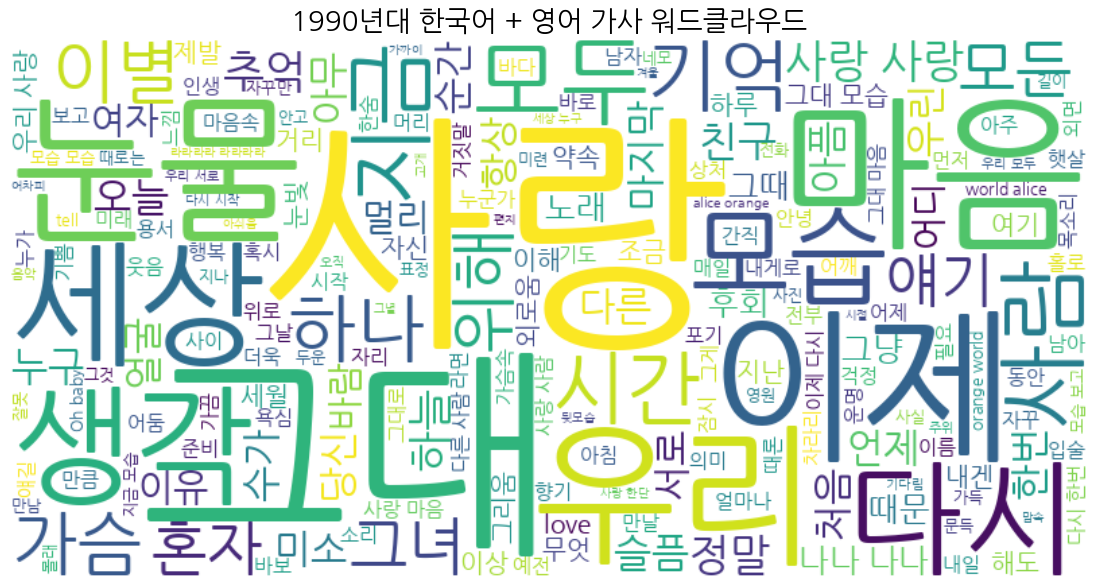

In [ ]:
# 시각화
from wordcloud import WordCloud # Import the WordCloud class

# Create a WordCloud object
wordcloud = WordCloud(font_path=font_path, width=800, height=400, background_color='white').generate(final_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("1990년대 한국어 + 영어 가사 워드클라우드", fontproperties=font_prop, fontsize=20)
plt.show()

In [ ]:
# 워드클라우드 결과에서 단어와 빈도수(정규화된 값)를 가져오기
words_freq = wordcloud.words_

# 빈도수가 높은 순서로 정렬
top_40_words = sorted(words_freq.items(), key=lambda x: x[1], reverse=True)[:40]

# 결과 출력
print("상위 40개 단어:")
for idx, (word, freq) in enumerate(top_40_words, 1):
    print(f"{idx}. {word}: {freq:.4f}")

상위 40개 단어:
1. 사랑: 1.0000
2. 그대: 0.7600
3. 마음: 0.3627
4. 이제: 0.3597
5. 눈물: 0.3186
6. 우리: 0.3139
7. 세상: 0.3026
8. 생각: 0.2781
9. 다시: 0.2674
10. 모습: 0.2561
11. 모두: 0.2501
12. 사람: 0.2341
13. 지금: 0.2126
14. 시간: 0.2085
15. 기억: 0.1977
16. 하나: 0.1751
17. 가슴: 0.1745
18. 이별: 0.1721
19. 위해: 0.1686
20. 그녀: 0.1412
21. 모든: 0.1382
22. 혼자: 0.1310
23. 얘기: 0.1275
24. 사랑 사랑: 0.1251
25. 추억: 0.1215
26. 하늘: 0.1209
27. 정말: 0.1161
28. 친구: 0.1108
29. 오늘: 0.1072
30. 슬픔: 0.1042
31. 언제: 0.0971
32. 미소: 0.0959
33. 누구: 0.0947
34. 다른: 0.0923
35. 처음: 0.0911
36. 아무: 0.0905
37. 당신: 0.0887
38. 항상: 0.0876
39. 마지막: 0.0852
40. 수가: 0.0840
